# Federated Learning 

> Splits the diabetes dataset into N independent client datasets, simulating hospitals that cannot share raw patient data. Only the model is shared — never the data.

---

## Strategy

Partitioning is done at the **patient level**: all encounters from the same patient go to the same client, so no patient can appear in two hospitals simultaneously. This prevents data leakage across clients.

| Stage | What it does |
|---|---|
| **1. Global schema** | Runs `prepare_data` once on the full dataset to learn the complete dummy column space |
| **2. Partition** | Shuffles patient IDs, splits into N chunks, writes each client's raw rows to disk |
| **3. Client prep** | Each client independently preprocesses, splits and scales its own data |

The only information shared between stages is `feature_schema.json` — a list of column names with no patient data — which guarantees identical feature dimensionality across all clients.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
import json
import os

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, roc_auc_score,
    classification_report
)
from xgboost import XGBClassifier
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
sys.path.append('..')

from UC1Utils import (
    prepare_data, ensure_data,
    prepare_data_aligned, derive_global_columns,
    split_data, scale_data,
    DATA_DIR, CSV_MAIN  
)

DATA_PATH  = CSV_MAIN  
OUTPUT_DIR = 'federated_data'
N_CLIENTS    = 5
ALPHA        = 0.5      # sweep: 0.5, 1.0, 5.0, 10.0
MIN_PATIENTS = 500
MIN_POS_RATE = 0.01     # lower threshold — minority class is genuinely sparse
MAX_RETRIES  = 500      # more retries for borderline α=0.5
SEED        = 42

ensure_data()

✓ CSV files already present, skipping extraction.


## Global Feature Schema

Run `prepare_data` once on the full dataset to discover the complete set of dummy columns that `get_dummies` would produce across all patients. This list becomes the shared contract that every client aligns to after their independent preprocessing.

This is the **only** step that touches the full dataset. Nothing here is shared with clients except the column names.

In [2]:
global_columns = derive_global_columns(DATA_PATH)

os.makedirs(OUTPUT_DIR, exist_ok=True)
schema_path = os.path.join(OUTPUT_DIR, 'feature_schema.json')
with open(schema_path, 'w') as f:
    json.dump(global_columns, f, indent=2)

print(f'Feature schema saved → {schema_path}')

Deriving global feature schema from full dataset...
  99 feature columns
Feature schema saved → federated_data/feature_schema.json


## Partition of Data into Clients

Shuffle all unique patient IDs with a seeded RNG and cut them into N equal chunks. Each client receives only its raw rows — no preprocessing happens here.

In [3]:
df_raw          = pd.read_csv(DATA_PATH)
unique_patients = df_raw['patient_nbr'].unique()

print(f'Total rows      : {len(df_raw):,}')
print(f'Unique patients : {len(unique_patients):,}')

rng      = np.random.default_rng(SEED)
shuffled = rng.permutation(unique_patients)
chunks   = np.array_split(shuffled, N_CLIENTS)

Total rows      : 101,766
Unique patients : 71,518


In [4]:
def find_feasible_params(df_raw, n_clients_list, alpha_list, 
                         min_patients=500, n_trials=500, seed=42):
    """
    For each (n_clients, alpha) combination, estimate the probability
    of finding a valid split by running n_trials Dirichlet draws.
    """
    rng = np.random.default_rng(seed)
    
    patient_labels = (
        df_raw.groupby('patient_nbr')['readmitted']
        .apply(lambda x: 1 if (x == '<30').any() else 0)
        .reset_index()
    )
    pos_patients = patient_labels[patient_labels['readmitted'] == 1]['patient_nbr'].values
    neg_patients = patient_labels[patient_labels['readmitted'] == 0]['patient_nbr'].values
    
    print(f"Total patients: {len(patient_labels):,} "
          f"| Positive: {len(pos_patients):,} ({len(pos_patients)/len(patient_labels)*100:.1f}%)")
    print(f"\n{'N_clients':>10} | {'Alpha':>8} | {'Min pos rate achievable':>24} | {'Size feasible':>14}")
    print("-" * 65)
    
    for n in n_clients_list:
        for alpha in alpha_list:
            min_pos_rates = []
            size_ok_count = 0
            
            for _ in range(n_trials):
                prop_pos = rng.dirichlet([alpha] * n)
                prop_neg = rng.dirichlet([alpha] * n)
                
                counts_pos = (prop_pos * len(pos_patients)).astype(int)
                counts_neg = (prop_neg * len(neg_patients)).astype(int)
                
                client_pos = counts_pos
                client_neg = counts_neg
                client_total = client_pos + client_neg
                
                if min(client_total) >= min_patients:
                    size_ok_count += 1
                    rates = client_pos / (client_total + 1e-9)
                    min_pos_rates.append(min(rates))
            
            size_pct = size_ok_count / n_trials * 100
            avg_min_rate = np.mean(min_pos_rates) if min_pos_rates else 0
            p5_min_rate  = np.percentile(min_pos_rates, 5) if min_pos_rates else 0
            
            print(f"{n:>10} | {alpha:>8.3f} | "
                  f"mean={avg_min_rate:.3f} p5={p5_min_rate:.3f}       | "
                  f"{size_pct:.0f}% of trials")

find_feasible_params(
    df_raw,
    n_clients_list = [5, 10],
    alpha_list     = [0.05, 0.1, 0.3, 0.5, 1.0],
    min_patients   = 500
)

Total patients: 71,518 | Positive: 8,834 (12.4%)

 N_clients |    Alpha |  Min pos rate achievable |  Size feasible
-----------------------------------------------------------------
         5 |    0.050 | mean=0.000 p5=0.000       | 1% of trials
         5 |    0.100 | mean=0.003 p5=0.000       | 11% of trials
         5 |    0.300 | mean=0.007 p5=0.000       | 58% of trials
         5 |    0.500 | mean=0.014 p5=0.000       | 83% of trials
         5 |    1.000 | mean=0.026 p5=0.002       | 99% of trials
        10 |    0.050 | mean=0.000 p5=0.000       | 0% of trials
        10 |    0.100 | mean=0.000 p5=0.000       | 0% of trials
        10 |    0.300 | mean=0.002 p5=0.000       | 10% of trials
        10 |    0.500 | mean=0.004 p5=0.000       | 37% of trials
        10 |    1.000 | mean=0.014 p5=0.001       | 83% of trials


In [5]:
def dirichlet_partition(df_raw, n_clients=N_CLIENTS, alpha=ALPHA, seed=SEED,
                        min_patients=MIN_PATIENTS, min_pos_rate=MIN_POS_RATE,
                        max_retries=MAX_RETRIES):
    rng = np.random.default_rng(seed)

    patient_labels = (
        df_raw.groupby('patient_nbr')['readmitted']
        .apply(lambda x: 1 if (x == '<30').any() else 0)
        .reset_index()
    )

    for attempt in range(max_retries):
        client_patient_ids = [[] for _ in range(n_clients)]

        for cls in [0, 1]:
            patients_in_class = patient_labels[
                patient_labels['readmitted'] == cls
            ]['patient_nbr'].values.copy()
            rng.shuffle(patients_in_class)

            proportions = rng.dirichlet([alpha] * n_clients)
            counts = (proportions * len(patients_in_class)).astype(int)
            counts[-1] = len(patients_in_class) - counts[:-1].sum()

            start = 0
            for k, n in enumerate(counts):
                client_patient_ids[k].extend(
                    patients_in_class[start:start+n].tolist()
                )
                start += n

        # Check both size and class diversity
        sizes = [len(c) for c in client_patient_ids]
        pos_rates = []
        for ids in client_patient_ids:
            labels = patient_labels[
                patient_labels['patient_nbr'].isin(ids)
            ]['readmitted']
            pos_rates.append(labels.mean())

        size_ok = min(sizes) >= min_patients
        rate_ok = min(pos_rates) >= min_pos_rate

        if size_ok and rate_ok:
            print(f"  Valid split on attempt {attempt + 1}.")
            print(f"  Sizes:     min={min(sizes):,}  max={max(sizes):,}")
            print(f"  Pos rates: min={min(pos_rates):.3f}  max={max(pos_rates):.3f}")
            return client_patient_ids

    raise ValueError(
        f"No valid split found after {max_retries} attempts. "
        f"Try fewer clients, higher alpha, or lower min_pos_rate."
    )

# Run partition
client_patient_ids = dirichlet_partition(df_raw, N_CLIENTS, ALPHA, SEED)

# Write to disk — same structure as before
manifest = {}
os.makedirs(OUTPUT_DIR, exist_ok=True)

for i, patient_ids in enumerate(client_patient_ids):
    client_dir = os.path.join(OUTPUT_DIR, f'client_{i}')
    os.makedirs(client_dir, exist_ok=True)
    
    client_df = df_raw[df_raw['patient_nbr'].isin(patient_ids)].copy()
    raw_path  = os.path.join(client_dir, 'raw_data.csv')
    client_df.to_csv(raw_path, index=False)
    
    pos_rate = (client_df['readmitted'] == '<30').mean() * 100
    manifest[f'client_{i}'] = {
        'n_patients'  : int(len(patient_ids)),
        'n_encounters': int(len(client_df)),
        'pos_rate_pct': round(pos_rate, 2),
        'raw_data'    : raw_path,
    }
    print(f'  client_{i}: {len(patient_ids):>6,} patients | '
          f'{len(client_df):>7,} encounters | '
          f'pos rate: {pos_rate:.1f}%')

# Save manifest with alpha recorded
manifest['_meta'] = {'alpha': ALPHA, 'n_clients': N_CLIENTS, 'seed': SEED}
with open(os.path.join(OUTPUT_DIR, 'manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=2)

  Valid split on attempt 3.
  Sizes:     min=2,694  max=33,534
  Pos rates: min=0.011  max=0.212
  client_0:  6,512 patients |   8,208 encounters | pos rate: 1.2%
  client_1: 18,025 patients |  22,525 encounters | pos rate: 1.6%
  client_2: 33,534 patients |  52,210 encounters | pos rate: 17.4%
  client_3: 10,753 patients |  14,843 encounters | pos rate: 8.4%
  client_4:  2,694 patients |   3,980 encounters | pos rate: 14.1%


In [6]:
# Verify zero patient leakage across all client pairs
print('Verifying zero patient leakage...')
all_sets = [set(chunk) for chunk in chunks]
for a in range(N_CLIENTS):
    for b in range(a + 1, N_CLIENTS):
        overlap = all_sets[a] & all_sets[b]
        assert len(overlap) == 0, \
            f'LEAK between client_{a} and client_{b}: {len(overlap)} patients'
print('✓ Zero leakage confirmed.')

Verifying zero patient leakage...
✓ Zero leakage confirmed.


## Client Preparation

Each client independently preprocesses its own raw CSV. No client has access to another client's data — the loop here simply simulates what would run on separate machines in a real deployment.

Each iteration:
1. Calls `prepare_data_aligned` on its own `raw_data.csv` — identical pipeline to the centralized baseline, plus schema alignment
2. Splits into train / val / test at the patient level
3. Fits a `StandardScaler` on its own training data only
4. Saves arrays, scaler and stats to its folder

In [7]:
client_info = {}

for i in range(N_CLIENTS):
    client_dir = os.path.join(OUTPUT_DIR, f'client_{i}')
    raw_path   = os.path.join(client_dir, 'raw_data.csv')
    print(f'\n── client_{i} {"─" * 50}')

    # Preprocess independently — aligned to global schema
    X, y, groups, feature_names = prepare_data_aligned(
        path           = raw_path,
        global_columns = global_columns,
        verbose        = True,
    )

    # Patient-level train / val / test split
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, groups, test_size=0.2, val_size=0.15, seed=SEED
    )
    print(f'Split  → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}')

    # Scale — fitted on this client's train only
    X_train_s, X_val_s, X_test_s, scaler = scale_data(X_train, X_val, X_test)

    # Save
    np.save(os.path.join(client_dir, 'X_train.npy'), X_train_s)
    np.save(os.path.join(client_dir, 'X_val.npy'),   X_val_s)
    np.save(os.path.join(client_dir, 'X_test.npy'),  X_test_s)
    np.save(os.path.join(client_dir, 'y_train.npy'), y_train)
    np.save(os.path.join(client_dir, 'y_val.npy'),   y_val)
    np.save(os.path.join(client_dir, 'y_test.npy'),  y_test)
    joblib.dump(scaler, os.path.join(client_dir, 'scaler.joblib'))

    info = {
        'n_train'      : int(len(X_train)),
        'n_val'        : int(len(X_val)),
        'n_test'       : int(len(X_test)),
        'n_features'   : int(X_train_s.shape[1]),
        'positive_rate': float(round(float(y_train.mean()), 4)),
    }
    with open(os.path.join(client_dir, 'client_info.json'), 'w') as f:
        json.dump(info, f, indent=2)

    client_info[f'client_{i}'] = info
    print(f'Positive rate  → {info["positive_rate"]:.3f}')
    print(f'Saved          → {client_dir}/')


── client_0 ──────────────────────────────────────────────────


dropna removed 138 rows (1.72%)
Dataset shape after cleaning: (7863, 101)
Class distribution:
readmitted_binary
0    7765
1      98
Name: count, dtype: int64
Split  → train: 5,345 | val: 942 | test: 1,576
Positive rate  → 0.013
Saved          → federated_data/client_0/

── client_1 ──────────────────────────────────────────────────
dropna removed 363 rows (1.65%)
Dataset shape after cleaning: (21588, 101)
Class distribution:
readmitted_binary
0    21232
1      356
Name: count, dtype: int64
Split  → train: 14,630 | val: 2,605 | test: 4,353
Positive rate  → 0.016
Saved          → federated_data/client_1/

── client_2 ──────────────────────────────────────────────────
dropna removed 742 rows (1.45%)
Dataset shape after cleaning: (50269, 101)
Class distribution:
readmitted_binary
0    41302
1     8967
Name: count, dtype: int64
Split  → train: 34,247 | val: 6,021 | test: 10,001
Positive rate  → 0.179
Saved          → federated_data/client_2/

── client_3 ────────────────────────────────────


─────────────────────────────────────────────────────────────────
  Client        Train      Val     Test   Features  Pos. rate
  ────────── ──────── ──────── ──────── ────────── ──────────
  client_0      5,345      942    1,576         99      0.013
  client_1     14,630    2,605    4,353         99      0.016
  client_2     34,247    6,021   10,001         99      0.179
  client_3      9,736    1,675    2,873         99      0.088
  client_4      2,540      455      826         99      0.137


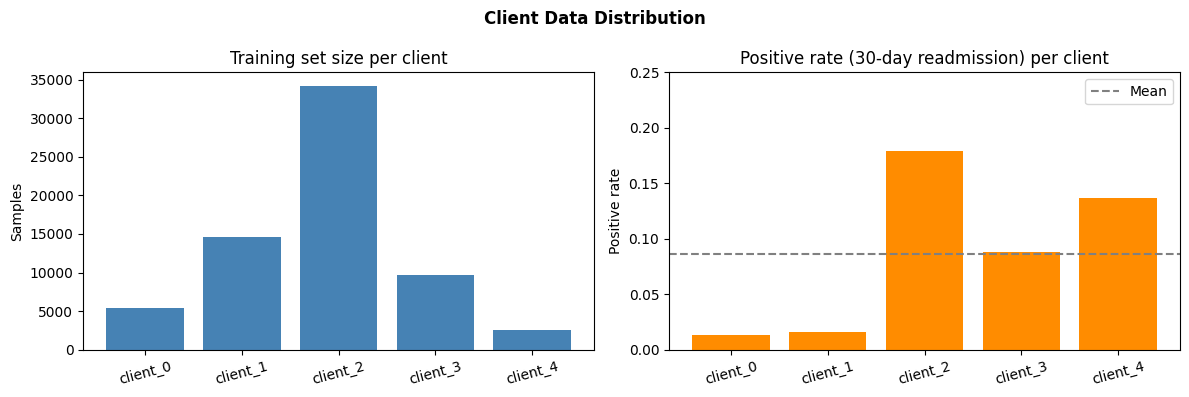

In [8]:
print(f'\n{"─" * 65}')
print(f'  {"Client":<10} {"Train":>8} {"Val":>8} {"Test":>8} {"Features":>10} {"Pos. rate":>10}')
print(f'  {"─"*10} {"─"*8} {"─"*8} {"─"*8} {"─"*10} {"─"*10}')
for k, v in client_info.items():
    print(f'  {k:<10} {v["n_train"]:>8,} {v["n_val"]:>8,} '
          f'{v["n_test"]:>8,} {v["n_features"]:>10,} {v["positive_rate"]:>10.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Client Data Distribution', fontweight='bold')

clients_keys     = list(client_info.keys())
train_sizes = [client_info[c]['n_train'] for c in clients_keys]
pos_rates   = [client_info[c]['positive_rate'] for c in clients_keys]

axes[0].bar(clients_keys, train_sizes, color='steelblue')
axes[0].set_title('Training set size per client')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(clients_keys, pos_rates, color='darkorange')
axes[1].axhline(sum(pos_rates) / len(pos_rates), color='gray',
                linestyle='--', label='Mean')
axes[1].set_title('Positive rate (30-day readmission) per client')
axes[1].set_ylabel('Positive rate')
axes[1].set_ylim(0, 0.25)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'client_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## Model Setup

In [9]:
# Here we add LayerNorm instead of BatchNorm, which is more stable for small batch sizes common in federated settings.
# The centralized baseline uses BatchNorm1d, while the federated models use LayerNorm, since FedAvg aggregation of 
# BatchNorm running statistics across heterogeneous clients produces corrupted normalization parameters
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, output_dim=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, output_dim)
        )

    def forward(self, x):
        return self.net(x)

In [12]:
# Load best params from the centralized MLP checkpoint
centralized_ckpt = torch.load('../01_Centralized/models/mlp_centralized.pt', map_location=device, weights_only=False)

best_p = centralized_ckpt['best_params']

FL_ROUNDS    = 30
LOCAL_EPOCHS = 10
HIDDEN_DIM   = best_p['hidden_dim']
DROPOUT      = best_p['dropout']
LR           = best_p['lr']
BATCH_SIZE   = best_p['batch_size']

print(f"Loaded from centralized checkpoint:")
print(f"  hidden_dim : {HIDDEN_DIM}")
print(f"  dropout    : {DROPOUT:.4f}")
print(f"  lr         : {LR:.6f}")
print(f"  batch_size : {BATCH_SIZE}")

Loaded from centralized checkpoint:
  hidden_dim : 512
  dropout    : 0.4291
  lr         : 0.002405
  batch_size : 1024


## FedAvg

In [13]:
# ── Local training function ───────────────────────────────────────────────────
def local_train(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """
    Train model on one client's data for a fixed number of epochs.
    Returns the updated state dict and the number of training samples.
    """
    loader = DataLoader(
        TensorDataset(X_train, y_train),
        batch_size=batch_size, shuffle=True
    )

    cw = compute_class_weight('balanced', classes=np.unique(y_train.numpy()), y=y_train.numpy())

    # If a client has only one class, fall back to unweighted loss
    if len(cw) < 2:
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.CrossEntropyLoss(
            weight=torch.tensor(cw, dtype=torch.float32).to(device)
        )
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_auc = 0.0
    best_state   = None

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_proba = torch.softmax(
                model(X_val.to(device)), dim=1
            )[:, 1].cpu().numpy()

        if len(np.unique(y_val.numpy())) > 1:
            val_auc = roc_auc_score(y_val.numpy(), val_proba)
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            # Single class client — fall back to saving last state
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    return best_state, len(X_train)


# ── FedAvg aggregation ────────────────────────────────────────────────────────
def fed_avg(state_dicts, sample_counts):
    """
    Weighted average of model parameters.
    Each client's contribution is proportional to its number of training samples.
    """
    total = sum(sample_counts)
    avg_state = {}

    for key in state_dicts[0].keys():
        avg_state[key] = sum(
            state_dicts[i][key] * (sample_counts[i] / total)
            for i in range(len(state_dicts))
        )

    return avg_state

In [14]:
# ── Federation loop ───────────────────────────────────────────────────────────
# Initialise one global model — all clients start from the same weights
best_global_auc = 0.0
best_global_state = None
patience = 5
rounds_without_improvement = 0

input_dim= client_info['client_0']['n_features']  # All clients have the same feature count after alignment
global_model = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)

clients = {}

for i in range(N_CLIENTS):
    client_dir = os.path.join(OUTPUT_DIR, f'client_{i}')
    clients[i] = {
        'X_train': torch.tensor(np.load(os.path.join(client_dir, 'X_train.npy')), dtype=torch.float32),
        'y_train': torch.tensor(np.load(os.path.join(client_dir, 'y_train.npy')), dtype=torch.long),
        'X_val'  : torch.tensor(np.load(os.path.join(client_dir, 'X_val.npy')),   dtype=torch.float32),
        'y_val'  : torch.tensor(np.load(os.path.join(client_dir, 'y_val.npy')),   dtype=torch.long),
        'X_test' : torch.tensor(np.load(os.path.join(client_dir, 'X_test.npy')),  dtype=torch.float32),
        'y_test' : torch.tensor(np.load(os.path.join(client_dir, 'y_test.npy')),  dtype=torch.long),
    }
    print(f'client_{i}: {len(clients[i]["y_train"]):,} train samples')

round_aucs = []  # global AUC after each round

for fl_round in range(FL_ROUNDS):
    print(f'\n─── Round {fl_round + 1}/{FL_ROUNDS} ───────────────────────────')

    state_dicts   = []
    sample_counts = []

    # ── Local training on each client ────────────────────────────────────────
    for i in range(N_CLIENTS):
        # Each client gets a copy of the current global model
        local_model = MLP(input_dim=input_dim, hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(device)
        local_model.load_state_dict(global_model.state_dict())

        state, n = local_train(
            model      = local_model,
            X_train    = clients[i]['X_train'],
            y_train    = clients[i]['y_train'],
            X_val      = clients[i]['X_val'],
            y_val      = clients[i]['y_val'],
            epochs     = LOCAL_EPOCHS,
            batch_size = BATCH_SIZE,
        )
        state_dicts.append(state)
        sample_counts.append(n)
        print(f'  client_{i}: trained on {n:,} samples')

    # ── Aggregate ─────────────────────────────────────────────────────────────
    global_state = fed_avg(state_dicts, sample_counts)
    global_model.load_state_dict(global_state)

    # ── Global evaluation (simulation only — concatenate all test sets) ───────
    global_model.eval()
    val_proba, val_y = [], []
    test_proba, test_y = [], []

    with torch.no_grad():
        for i in range(N_CLIENTS):
            # Val evaluation
            logits = global_model(clients[i]['X_val'].to(device))
            val_proba.append(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
            val_y.append(clients[i]['y_val'].numpy())

            # Test evaluation (only for tracking, not for early stopping)
            logits = global_model(clients[i]['X_test'].to(device))
            test_proba.append(torch.softmax(logits, dim=1)[:,1].cpu().numpy())
            test_y.append(clients[i]['y_test'].numpy())

    val_auc  = roc_auc_score(np.concatenate(val_y),  np.concatenate(val_proba))
    test_auc = roc_auc_score(np.concatenate(test_y), np.concatenate(test_proba))
    print(f'  Val AUC: {val_auc:.4f} | Test AUC: {test_auc:.4f}')

    # Early stopping on val AUC
    if val_auc > best_global_auc:
        best_global_auc = val_auc
        best_global_state = {k: v.clone() for k, v in global_model.state_dict().items()}
        rounds_without_improvement = 0
    else:
        rounds_without_improvement += 1
        if rounds_without_improvement >= patience:
            print(f'\nEarly stopping at round {fl_round+1} '
                  f'(no val improvement for {patience} rounds)')
            break

    # Load best global model before final evaluation
    global_model.load_state_dict(best_global_state)
    print(f'  Global AUC: {val_auc:.4f}')

client_0: 5,345 train samples
client_1: 14,630 train samples
client_2: 34,247 train samples
client_3: 9,736 train samples
client_4: 2,540 train samples

─── Round 1/30 ───────────────────────────
  client_0: trained on 5,345 samples
  client_1: trained on 14,630 samples
  client_2: trained on 34,247 samples
  client_3: trained on 9,736 samples
  client_4: trained on 2,540 samples
  Val AUC: 0.6350 | Test AUC: 0.6245
  Global AUC: 0.6350

─── Round 2/30 ───────────────────────────
  client_0: trained on 5,345 samples
  client_1: trained on 14,630 samples
  client_2: trained on 34,247 samples
  client_3: trained on 9,736 samples
  client_4: trained on 2,540 samples
  Val AUC: 0.6355 | Test AUC: 0.6231
  Global AUC: 0.6355

─── Round 3/30 ───────────────────────────
  client_0: trained on 5,345 samples
  client_1: trained on 14,630 samples
  client_2: trained on 34,247 samples
  client_3: trained on 9,736 samples
  client_4: trained on 2,540 samples
  Val AUC: 0.6354 | Test AUC: 0.6210
  

In [15]:
# ── Per-client evaluation with final global model ─────────────────────────────
print('\n=== Per-client results (final global model) ===')
global_model.eval()

with torch.no_grad():
    for i in range(N_CLIENTS):
        logits = global_model(clients[i]['X_test'].to(device))
        proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        auc    = roc_auc_score(clients[i]['y_test'].numpy(), proba)
        print(f'\nclient_{i} — AUC: {auc:.4f}')
        print(classification_report(clients[i]['y_test'].numpy(), preds))


=== Per-client results (final global model) ===

client_0 — AUC: 0.7567
              precision    recall  f1-score   support

           0       0.99      0.63      0.77      1557
           1       0.02      0.74      0.05        19

    accuracy                           0.63      1576
   macro avg       0.51      0.68      0.41      1576
weighted avg       0.98      0.63      0.76      1576


client_1 — AUC: 0.7049
              precision    recall  f1-score   support

           0       0.99      0.64      0.78      4277
           1       0.03      0.63      0.06        76

    accuracy                           0.64      4353
   macro avg       0.51      0.64      0.42      4353
weighted avg       0.97      0.64      0.77      4353


client_2 — AUC: 0.6107
              precision    recall  f1-score   support

           0       0.86      0.65      0.74      8260
           1       0.24      0.52      0.32      1741

    accuracy                           0.63     10001
   macr

In [16]:
# ── Save FedAvg results ────────────────────────────────────────────────────────

os.makedirs('results', exist_ok=True)

# Collect per-client AUC from the evaluation already done above
global_model.eval()
all_proba, all_y = [], []
per_client_auc = {}

with torch.no_grad():
    for i in range(N_CLIENTS):
        logits = global_model(clients[i]['X_test'].to(device))
        proba  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        y_test = clients[i]['y_test'].numpy()
        all_proba.append(proba)
        all_y.append(y_test)
        if len(np.unique(y_test)) > 1:
            per_client_auc[str(i)] = float(roc_auc_score(y_test, proba))

global_test_auc = float(roc_auc_score(
    np.concatenate(all_y), np.concatenate(all_proba)
))

# round_aucs already collected in the loop above as:
# round_aucs = []  ← you need to add this list to your federation loop
# inside the loop: round_aucs.append({'val': val_auc, 'test': test_auc})

results_fedavg = {
    'alpha':      ALPHA,
    'n_clients':  N_CLIENTS,
    'test_auc':   global_test_auc,
    'per_client': per_client_auc,
    'round_aucs': round_aucs,     # val+test AUC per round
}

with open(f'results/fedavg_alpha{ALPHA}.json', 'w') as f:
    json.dump(results_fedavg, f, indent=2)

print(f'FedAvg results saved → results/fedavg_alpha{ALPHA}.json')
print(f'Global test AUC: {global_test_auc:.4f}')

FedAvg results saved → results/fedavg_alpha0.5.json
Global test AUC: 0.6176
